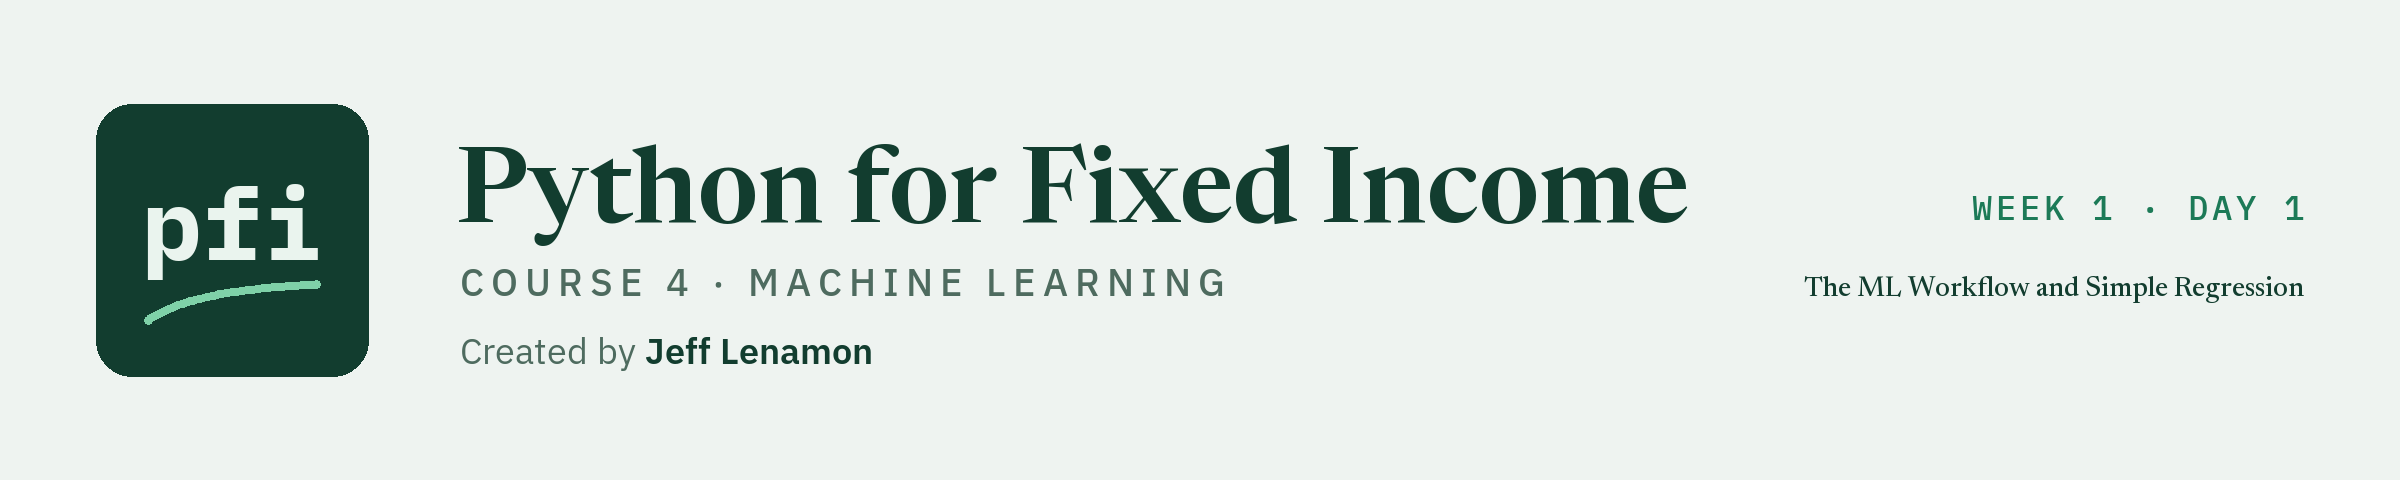

# The ML Workflow and Simple Regression

Week 1, Day 1. Machine learning on a desk means a function fitted to rows and judged on rows it never saw. Today: the workflow and where it fails in finance, the split that keeps test rows away, scikit-learn's build, fit, and output pattern, and errors measured in bp.

**Data:** `benchmark.csv` and `ratings.csv`, 821 bonds of invented issuers: **synthetic**, made for this course by `tools/make_holdings.py`. No real issuer, price, or spread.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week1/day1/01_the_ml_workflow_and_simple_regression.ipynb)

In Course 1, notebook 12, you drew a straight line of OAS on rating score through the 200 bonds of the holdings file. It rose 42.45 bp per notch and its R squared was 0.55. That line described the bonds it was drawn through, all of them at once. Nothing was held back to see how it does on bonds it had not seen.

Today the same line becomes a **model**: fitted on some bonds, then judged on bonds it never saw, with its errors in bp. That one change, holding rows back, is most of what separates machine learning from drawing a trendline, and most of what goes wrong with it in finance goes wrong there.

**The data is synthetic.** The 821 bonds of `benchmark.csv` belong to invented issuers, and their spreads were generated by the course's own script, `tools/make_holdings.py`, from each bond's rating, its maturity, an effect shared by each issuer's bonds, and random noise. A regression on them can recover part of that recipe and nothing about any real market. Section 1.8 shows the recipe beside what the line finds.

Today you will:

1. Say what machine learning is in this course: rows, features, a target, a fitted function.
2. Walk through the workflow and the five ways it fails in finance, a table the course comes back to.
3. Recall Course 1's line, now on all 821 bonds.
4. Split the rows with `train_test_split` and prove no bond is on both sides with `assert_disjoint`.
5. Fit a line with scikit-learn: build, fit, then ask for its output.
6. Measure R-squared, MAE, and RMSE in bp with `regression_metrics`, on training and test rows.
7. Say what the fitted line is, and what it is not.
8. Look at the recipe behind the spreads.

Q. Set up today's work folder: the thread settings, the seed, and today's three data files.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_01_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_01_86oe4n9s, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv
SEED = 42


* The first lines set two thread settings **before** numpy, pandas, or scikit-learn is imported. With one thread, the libraries add numbers up in the same order every time, so every run of this notebook prints the same last digits. If you ran another cell first, restart the kernel and run the setup cell first.
* `SEED = 42` is the course's one seed. Wherever a function makes a random choice (which rows go to the test set today; later, how a tree breaks a tie or where K-means starts), it gets `random_state=SEED`, so every run makes the same choice.

> **STORY: why the seed is 42.** scikit-learn's own glossary, under `random_state`, says: "Using an int will produce the same results across different calls. However, it may be worthwhile checking that your results are stable across a number of different distinct random seeds. Popular integer random seeds are 0 and 42." The 42 in that sentence links to a Wikipedia article about Douglas Adams's *The Hitchhiker's Guide to the Galaxy*, in which a computer called Deep Thought gives 42 as the answer to the ultimate question of life, the universe, and everything. In 1993 a reader asked on the newsgroup alt.fan.douglas-adams why the answer was 42, and Adams replied: "The answer to this is very simple. It was a joke. It had to be a number, an ordinary, smallish number, and I chose that one."
>
> So 42 is a habit with a joke behind it. Any whole number makes a run repeatable, and no number makes a model better. The glossary's own advice is the useful part: once a result matters, check that it holds under other seeds too.
>
> Sources (read 2026-10-04): scikit-learn glossary, `random_state`, https://scikit-learn.org/stable/glossary.html#term-random_state; Wikipedia, "Phrases from The Hitchhiker's Guide to the Galaxy" (a secondary source), https://en.wikipedia.org/wiki/Phrases_from_The_Hitchhiker%27s_Guide_to_the_Galaxy; Douglas Adams, alt.fan.douglas-adams, 3 November 1993, Internet Archive copy, https://web.archive.org/web/20080201064612/https://groups.google.com/group/alt.fan.douglas-adams/msg/d1064f7b27808692?dmode=source

## 1.1 What Machine Learning Is Here

In this course, machine learning is plain: **a function fitted to rows of data, then judged on rows it did not see.** The words, in desk terms:

| Word | Meaning | Today |
| --- | --- | --- |
| Row | One observation | One bond |
| Feature | A column the function reads | Rating score, 1 for AAA to 18 for CCC |
| Target | The column the function is fitted to | OAS in bp |
| Model | A function with numbers fitted from data | A straight line: an intercept and a slope |
| Training rows | The rows the numbers are fitted on | Three quarters of the bonds |
| Test rows | Rows kept out of the fit, used once to report errors | The other quarter |

Q. Load the bonds and give each one its rating score.

The bonds are invented, and their spreads come from the course's generator, not from any market.

In [2]:
# the 821 synthetic benchmark bonds, and the rating table that numbers the ratings
bench = pd.read_csv("benchmark.csv", float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")

# add each bond's rating score and grade; validate= stops if a rating appears twice in ratings.csv
bench = bench.merge(ratings[["rating", "score", "grade"]], on="rating", how="left", validate="many_to_one")
assert bench["score"].notna().all(), "a bond has a rating that ratings.csv does not list"

print(f"{len(bench):,} bonds of {bench['ticker'].nunique()} invented issuers, {bench.shape[1]} columns")
bench[["cusip", "issuer", "sector", "rating", "score", "oas", "duration"]].head()

821 bonds of 150 invented issuers, 21 columns


,cusip,issuer,sector,rating,score,oas,duration
0,99001BAA4,Quorvane Energy,Energy,BBB,9,83,6.000
1,99001BAB2,Quorvane Energy,Energy,BBB,9,122,6.834
2,99001BAC0,Quorvane Energy,Energy,BBB,9,123,9.848
3,99001BAD8,Quorvane Energy,Energy,BBB,9,88,0.933
4,99001BAE6,Quorvane Energy,Energy,BBB,9,127,6.256


* Every bond has a score: the `assert` would have stopped the notebook if a rating were missing from the table.

Q. Which column is the target, and which is the feature?

In [3]:
# the features X: a DataFrame, so two pairs of brackets, even for one column
X = bench[["score"]]   # rating score, 1 (AAA) to 18 (CCC)
# the target y: a Series of OAS in bp
y = bench["oas"]

print(f"X: {X.shape[0]:,} rows by {X.shape[1]} column; y: {len(y):,} spreads in bp, from {y.min()} to {y.max()}")

X: 821 rows by 1 column; y: 821 spreads in bp, from 15 to 2074


* scikit-learn wants the features as a table (rows by columns) even when there is one column, which is why `X` has two pairs of brackets and `y` one. The course names them `X` and `y` every day, as the library's documentation and nearly every tutorial do.

## 1.2 The Workflow, and Where It Fails in Finance

Every model in this course goes through the same seven steps. Today's are filled in:

| Step | What it means | Today |
| --- | --- | --- |
| 1. Question | What the model is for, in one sentence | How much of a bond's OAS does its rating score account for, in this file? |
| 2. Rows and columns | Which rows, which features, which target | 821 bonds; feature `score`; target `oas` in bp |
| 3. Split first | Put the test rows away before computing anything for the model | 615 training rows, 206 test rows |
| 4. Fit | Fit the model's numbers on the training rows only | A straight line |
| 5. Choose | Choose settings on rows the test set never sees | Nothing to choose today; week 2 adds validation rows |
| 6. Report | Use the test rows once, for the reported errors | R-squared, MAE, RMSE in bp |
| 7. Describe | Say what the model shows and where it fails | Section 1.7 |

The same steps fail in finance in five ways. Each one makes a model look better than it is, and none of them raises an error:

| Failure | What it looks like | Where the course meets it |
| --- | --- | --- |
| Lookahead | A number for a date that uses data from after that date | Course 3 day 7; day 11 |
| Leakage | Test rows, or a statistic of them, inside the training; the target hidden in a feature | Today's AI check; days 3, 5, 10 |
| A metric that hides the rare case | A model that is right on most accounts and catches no defaults | Day 7 |
| Rows that are not independent | Bonds of one issuer; days next to each other | Below; days 3, 5, 11 |
| A model read as a view | A fitted spread treated as something it is not | Section 1.7, every day |

Q. Are the rows in this file independent of each other?

In [4]:
# how many bonds each issuer has in the file
bonds_per_issuer = bench.groupby("ticker").size()
print(f"{bench['ticker'].nunique()} issuers; from {bonds_per_issuer.min()} to {bonds_per_issuer.max()} bonds each, "
      f"{bonds_per_issuer.mean():.1f} on average")

150 issuers; from 3 to 8 bonds each, 5.5 on average


* 150 issuers hold 821 bonds, from 3 to 8 each. The generator gives all the bonds of one issuer the same issuer effect, so they are not independent: a model can learn an issuer from its bonds in the training rows and meet the same issuer again in the test rows. Section 1.4 counts how often that happens; day 5 splits by issuer and measures what it changes.
* One more fact about the files: all 200 bonds of `holdings.csv` are also in `benchmark.csv`. The holdings are never used as a test set for a model fitted on the benchmark, because the model would have seen every one of them.

## 1.3 Course 1's Line, Now as a Model

Course 1's line on the holdings started at -169.17 bp at score 1: a straight line through spreads that rise faster at the bottom of the scale than at the top goes below zero for the best ratings. First, the same description on all 821 benchmark bonds.

Q. Draw the straight line of OAS on rating score through every bond, as Course 1 did.

This is **description**: the line is drawn through all the rows and nothing is held back, so it says how well a line fits these bonds, not how it does on bonds it has not seen. No number from it is used to build the model.

all 821 bonds: slope 39.2998 bp per notch, intercept -184.3842 bp, R-squared 0.5289
the line at score 1 (AAA): -145.1 bp


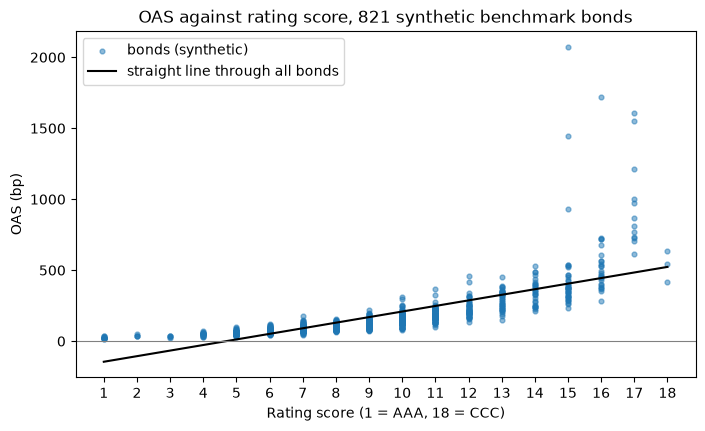

In [5]:
import matplotlib.pyplot as plt

# np.polyfit with degree 1 returns the slope, then the intercept, of the least squares line
slope_all, intercept_all = np.polyfit(bench["score"], bench["oas"], 1)
r_squared_all = bench["score"].corr(bench["oas"]) ** 2
print(f"all {len(bench)} bonds: slope {slope_all:.4f} bp per notch, intercept {intercept_all:.4f} bp, "
      f"R-squared {r_squared_all:.4f}")
print(f"the line at score 1 (AAA): {intercept_all + slope_all * 1:.1f} bp")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(bench["score"], bench["oas"], s=12, alpha=0.5, label="bonds (synthetic)")
scores = np.arange(1, 19)
ax.plot(scores, intercept_all + slope_all * scores, color="black", label="straight line through all bonds")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xticks(scores)
ax.set_title("OAS against rating score, 821 synthetic benchmark bonds")
ax.set_xlabel("Rating score (1 = AAA, 18 = CCC)")
ax.set_ylabel("OAS (bp)")
ax.legend()
plt.show()

* A slope of 39.3 bp per notch and an R-squared of 0.5289: the line accounts for about 53% of the variation in OAS around its mean. At score 1 it gives -145.1 bp, below zero, the same shape as Course 1's.
* The chart shows why. Spreads fan out and curve upward as ratings fall; a straight line splits the difference and misses the bottom of the scale by hundreds of bp.

Q. Does the line match Excel's `SLOPE`, `INTERCEPT`, and `RSQ` over the same 821 bonds?

In [6]:
# Excel's values, computed in Excel over all 821 bonds (the course's Excel reference file)
reference = pd.read_csv("course4_excel_reference.csv", float_precision="round_trip").set_index("case_id")
excel_all = reference.loc[["d01_oas_on_score:slope", "d01_oas_on_score:intercept", "d01_oas_on_score:rsq"], "excel_value"]
python_all = [slope_all, intercept_all, r_squared_all]

for name, excel_value, python_value in zip(["SLOPE", "INTERCEPT", "RSQ"], excel_all, python_all):
    print(f"{name:9} Excel {excel_value:12.6f}   Python {python_value:12.6f}   within 1e-9: {abs(excel_value - python_value) < 1e-9}")

SLOPE     Excel    39.299808   Python    39.299808   within 1e-9: True
INTERCEPT Excel  -184.384215   Python  -184.384215   within 1e-9: True
RSQ       Excel     0.528917   Python     0.528917   within 1e-9: True


* The same three numbers. Excel wrote `=SLOPE(bench!$A$2:$A$822,bench!$B$2:$B$822)` for the slope, with OAS in column A and the score in column B of a sheet named `bench`. Course 1 showed these functions on the holdings; the reference file holds them for the benchmark.

## 1.4 The Split: Put the Test Rows Away

A model is judged on rows it did not see, so some rows must be put away **before** the model sees anything. `train_test_split` shuffles the row labels and cuts them in two. `test_size=0.25` sends a quarter of the rows to the test set; `random_state=SEED` fixes the shuffle, so every run puts the same bonds on each side.

Q. Split the bonds into training and test rows.

In [7]:
from sklearn.model_selection import train_test_split

# a quarter of the bonds go to the test set; SEED fixes which ones
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)

print(f"training rows: {len(X_train):,}; test rows: {len(X_test):,}")
print(f"first five training labels: {X_train.index[:5].tolist()}")
print(f"first five test labels:     {X_test.index[:5].tolist()}")

training rows: 615; test rows: 206
first five training labels: [712, 181, 778, 716, 636]
first five test labels:     [609, 174, 67, 168, 275]


* 615 training rows and 206 test rows. The labels are the rows' positions in `bench`, shuffled: the split keeps each bond's label, so you can always find which bond went where.

Q. Does the same seed give the same split again?

In [8]:
# split again with the same seed and compare the labels on each side
X_train_again, X_test_again, y_train_again, y_test_again = train_test_split(X, y, test_size=0.25, random_state=SEED)
print(f"same training rows: {X_train_again.index.equals(X_train.index)}; same test rows: {X_test_again.index.equals(X_test.index)}")

same training rows: True; same test rows: True


* The same rows, label for label. That is all a seed does: it makes the random choice repeatable.

**Why the test rows are put away.** Every number you compute from the test rows before the end is a chance for them to shape the model: a column dropped because it looked weak on them, a setting tuned until their error fell. Each step looks harmless, and together they turn the test set into more training data, so the reported error stops meaning "on bonds the model never saw". In this course the test rows are used once, for the reported numbers.

Q. Start `mlkit.py`, the module you build through this course, with the first check every split gets: no row on both sides.

Read the docstring before you run the cell. It states what goes in, what comes out, the convention, and what stops it.

In [9]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")

Writing mlkit.py


* `assert_disjoint` turns the labels of each part into a set and looks for labels in both. It **raises** rather than returning `True` or `False`, so a leak stops the notebook instead of printing a word that is easy to miss.

Q. Start `test_mlkit.py` with two tests: one split that passes, one that must fail with the count in its message.

In [10]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])

Writing test_mlkit.py


* The test file also holds helpers the later tests use: `read_bench` loads the bonds the way section 1.1 did, and `excel` reads one value from the Excel reference file.

Q. Import the module and run the tests.

In [11]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint']


In [12]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..                                                                       [100%]
2 passed in 1.18s



* `2 passed`. pytest found the two functions whose names start with `test_` and ran each one.

Q. Is any bond in both the training and the test rows?

In [13]:
# stops with an AssertionError if any label is on both sides
mlkit.assert_disjoint(X_train.index, X_test.index)
print(f"no bond is in both parts: {len(X_train)} training rows, {len(X_test)} test rows")

no bond is in both parts: 615 training rows, 206 test rows


Q. What does a leak look like? Copy five training bonds into the test rows on purpose.

In [14]:
# a mistake made on purpose: the test labels plus the first five training labels
leaky_test_index = X_test.index.append(X_train.index[:5])
try:
    mlkit.assert_disjoint(X_train.index, leaky_test_index)
except AssertionError as error:
    print(f"AssertionError: {error}")

AssertionError: 5 row labels are in both the training and the test rows


* The check names the count, so you know how big the leak is. Real leaks are rarely this plain: a row that appears twice in a file, or a model fitted before the split, does the same thing quietly. Today's AI check is one of them.

Q. Bonds are not the only thing that can be on both sides. How many test bonds share an issuer with a training bond?

In [15]:
# the issuers of the training bonds, and the test bonds whose issuer is among them
training_issuers = set(bench.loc[X_train.index, "ticker"])
shares_issuer = bench.loc[X_test.index, "ticker"].isin(training_issuers)
print(f"{shares_issuer.sum()} of {len(X_test)} test bonds have an issuer with bonds in the training rows")

203 of 206 test bonds have an issuer with bonds in the training rows


* 203 of 206. No bond is on both sides, but nearly every issuer is. Today's only feature, the rating score, does not name the issuer, so the line cannot learn one. When a later model gets features that identify the issuer, the split must keep each issuer on one side (day 5).

## 1.5 scikit-learn's Pattern: Build, Fit, Then Ask for Output

Every model in scikit-learn works the same three ways:

1. **Build** it: `LinearRegression()` makes an empty model, with no numbers fitted yet.
2. **Fit** it: `.fit(X_train, y_train)` fits its numbers on the rows you give it, here by least squares.
3. **Ask for its output**: `.predict(X)` returns the model's output for any rows you give it. `predict` is the method's name in scikit-learn; it means "compute the fitted value for these rows". On this course's data it never refers to the future of a market. The text calls the result the model's output, or a fitted value.

Q. Fit the straight line on the training rows only.

In [16]:
from sklearn.linear_model import LinearRegression

# 1. build: an empty straight-line model
model = LinearRegression()
# 2. fit: least squares on the training rows only; the test rows stay put away
model.fit(X_train, y_train)

# the fitted numbers: coef_ holds one slope per feature, intercept_ the intercept, both in bp
print(f"slope {model.coef_[0]:.4f} bp per notch; intercept {model.intercept_:.4f} bp")

slope 39.0526 bp per notch; intercept -179.0571 bp


* 39.0526 bp per notch, close to the 39.2998 of all the bonds, because three quarters of the bonds are the same.

Q. What does the model give for one bond of each of six ratings?

In [17]:
# 3. the model's output for rows it is given: six made-up bonds, one per rating
new_bonds = pd.DataFrame({"score": [1, 6, 9, 12, 15, 18]})
new_bonds["rating"] = new_bonds["score"].map(ratings.set_index("score")["rating"])
new_bonds["fitted_oas_bp"] = model.predict(new_bonds[["score"]]).round(1)
new_bonds

,score,rating,fitted_oas_bp
0,1,AAA,-140.0
1,6,A,55.3
2,9,BBB,172.4
3,12,BB,289.6
4,15,B,406.7
5,18,CCC,523.9


* These are **fitted spreads**: the model's spread for a bond with this rating score, and nothing else. The line gives -140.0 bp for AAA and 523.9 bp for CCC. Every rating score up to 4 gets a fitted spread below zero, which no bond in the file has.

Q. Does Excel's `SLOPE`, `INTERCEPT`, and `RSQ` on the same 615 training rows give the same line?

In [18]:
# Excel's values on the training rows (sheet "train": OAS in A2:A616, score in B2:B616), from the day's Excel check
excel_train = {"slope": 39.05261948386054, "intercept": -179.0570558960487, "R-squared (RSQ)": 0.5227499437906958}
# model.score returns the R-squared on the rows given
python_train = {"slope": model.coef_[0], "intercept": model.intercept_, "R-squared (RSQ)": model.score(X_train, y_train)}

comparison = pd.DataFrame({"Excel": excel_train, "Python": python_train})
comparison["within 1e-9"] = (comparison["Excel"] - comparison["Python"]).abs() < 1e-9
comparison

,Excel,Python,within 1e-9
slope,39.052619,39.052619,True
intercept,-179.057056,-179.057056,True
R-squared (RSQ),0.522750,0.522750,True


* The same line. In Excel, with the training rows pasted on a sheet named `train`, OAS in A and score in B: `=SLOPE(A2:A616,B2:B616)` in E1, `=INTERCEPT(A2:A616,B2:B616)` in E2, `=RSQ(A2:A616,B2:B616)` in E3. On the rows a line was fitted to, `RSQ` (the squared correlation) equals the R-squared; section 1.6 shows where that stops being true.

## 1.6 R-squared, MAE, and RMSE, in bp

Three numbers describe how far fitted values are from the actual ones:

| Metric | Formula | Unit | Reads as |
| --- | --- | --- | --- |
| R-squared | 1 - (sum of squared errors) / (sum of squared deviations from the mean) | none | The share of the variation around the mean that the fitted values account for. On test rows it can be negative |
| MAE | mean of the absolute errors | bp | The typical miss, in bp |
| RMSE | square root of the mean squared error | bp | Like MAE, but large misses count more |

A desk reads an error in bp, so **the course's main number for a spread model is the test MAE in bp**, with R-squared beside it.

Q. Add `regression_metrics` to `mlkit.py`, docstring first.

In [19]:
%%writefile -a mlkit.py


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}

Appending to mlkit.py


* `_as_1d_array` starts with an underscore: a helper for the module's own functions, not part of what it offers. It refuses an empty input or a table where a single column of numbers was expected.
* The docstring names the unit (the target's), the convention (equal to scikit-learn's functions), the Excel formulas, and what raises.

Q. Add the three tests: hand values, agreement with scikit-learn, and Excel's reference values.

In [20]:
%%writefile -a test_mlkit.py


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)

Appending to test_mlkit.py


* The hand test uses three bonds whose errors are 10, -10, and 30 bp, small enough to check on paper. The Excel test compares with `AVERAGE(ABS(...))` and `SQRT(SUMXMY2(...)/COUNT(...))` computed by Excel over all the bonds.

Q. Reload the module and run all the tests.

In [21]:
# the file changed, so reload before using the new function
importlib.reload(mlkit)
print(f"regression_metrics in mlkit: {hasattr(mlkit, 'regression_metrics')}")

regression_metrics in mlkit: True


In [22]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.....                                                                    [100%]
5 passed in 1.19s



* `5 passed`: this morning there was no module, and now there are five tests behind it.

Q. How far is the line from the actual spreads, on the training rows and on the test rows?

In [23]:
# the model's output for the training rows, and for the test rows, used here for the reported numbers
fitted_train = model.predict(X_train)
fitted_test = model.predict(X_test)

errors_table = pd.DataFrame({
    "training rows": mlkit.regression_metrics(y_train, fitted_train),
    "test rows": mlkit.regression_metrics(y_test, fitted_test),
}).T.rename(columns={"r2": "R-squared", "mae": "MAE (bp)", "rmse": "RMSE (bp)"})
errors_table.round({"R-squared": 4, "MAE (bp)": 1, "RMSE (bp)": 1})

,R-squared,MAE (bp),RMSE (bp)
training rows,0.5227,65.6,133.0
test rows,0.5529,57.7,108.3


* On the test rows the line misses by 57.7 bp on average (MAE), with an RMSE of 108.3 bp and an R-squared of 0.5529. The RMSE is almost twice the MAE: a few bonds are missed by hundreds of bp, and squaring makes them count.
* The test rows came out slightly **better** than the training rows (0.5529 against 0.5227). That is luck of one split, not a model that does better on new bonds: of the 10 largest misses among all 821 bonds, 7 landed in the training rows and 3 in the test rows. With a few hundred rows, one split can move a metric by this much. Day 5 splits several ways to see how much.

Q. Do the module's numbers equal scikit-learn's own metric functions?

In [24]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

test_metrics = mlkit.regression_metrics(y_test, fitted_test)
print(f"R-squared equal to r2_score:              {abs(test_metrics['r2'] - r2_score(y_test, fitted_test)) < 1e-12}")
print(f"MAE equal to mean_absolute_error:         {abs(test_metrics['mae'] - mean_absolute_error(y_test, fitted_test)) < 1e-12}")
print(f"RMSE equal to root_mean_squared_error:    {abs(test_metrics['rmse'] - root_mean_squared_error(y_test, fitted_test)) < 1e-12}")

R-squared equal to r2_score:              True
MAE equal to mean_absolute_error:         True
RMSE equal to root_mean_squared_error:    True


* Equal to 1e-12. The module does not replace scikit-learn's functions; it pins the course's three numbers in one place, with units, so every day reports the same set the same way.

Q. Draw the actual spread against the fitted spread for the test rows.

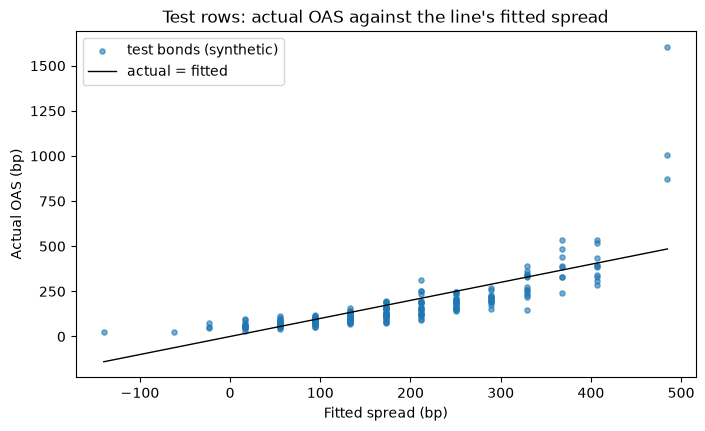

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(fitted_test, y_test, s=14, alpha=0.6, label="test bonds (synthetic)")
# the line where actual equals fitted, across the range of fitted spreads
low, high = fitted_test.min(), fitted_test.max()
ax.plot([low, high], [low, high], color="black", linewidth=1, label="actual = fitted")
ax.set_title("Test rows: actual OAS against the line's fitted spread")
ax.set_xlabel("Fitted spread (bp)")
ax.set_ylabel("Actual OAS (bp)")
ax.legend()
plt.show()

* A bond on the black line is fitted exactly. Above it, the actual spread is wider than the fitted spread; below it, tighter. At the left end every bond sits above the line, because the line goes below zero there; at the right end 3 bonds sit more than 300 bp above it. The misses grow with the fitted spread: a straight line in rating score is the wrong shape for these spreads.

## 1.7 What the Fitted Line Is, and What It Is Not

A model's output gets a name in this course, and only a name the course allows. For a spread model on the synthetic bonds:

| Allowed | What it means |
| --- | --- |
| fitted spread | The line's value at a bond's rating score |
| the model's spread for a bond with these characteristics | The same, said in full |
| residual | Actual OAS minus fitted spread, in bp |

A fitted spread is never called a fair value or a fair spread, and a residual never makes a bond cheap, rich, or mispriced, or a signal, a target, or a trade. The line knows one column, the rating score, of invented bonds; a gap between a bond and the line says how much of that bond's spread the line misses, and nothing about what anyone should do.

Q. Which test bonds does the line miss by the most?

In [26]:
# actual, fitted, and residual for each test bond, in bp
test_bonds = bench.loc[X_test.index, ["cusip", "issuer", "rating", "oas"]].copy()
test_bonds["fitted_oas_bp"] = fitted_test.round(1)
test_bonds["residual_bp"] = (y_test - fitted_test).round(1)

print(f"test bonds with a fitted spread below zero: {(fitted_test < 0).sum()} of {len(X_test)}")
# the five largest residuals in either direction
test_bonds.loc[test_bonds["residual_bp"].abs().sort_values(ascending=False).index[:5]]

test bonds with a fitted spread below zero: 5 of 206


,cusip,issuer,rating,oas,fitted_oas_bp,residual_bp
196,99038MAC3,Praxiskan Finance,CCC+,1605,484.8,1120.2
199,99038MAF6,Praxiskan Finance,CCC+,1004,484.8,519.2
198,99038MAE9,Praxiskan Finance,CCC+,871,484.8,386.2
78,99015PAA7,Praxane Paper,BB-,147,328.6,-181.6
393,99074WAB8,Wyxundra Energy,B+,532,367.7,164.3


* The largest residual belongs to Praxiskan Finance's `99038MAC3`, rated CCC+: its OAS is 1,605 bp and its fitted spread 484.8 bp, a residual of 1,120.2 bp. The issuer is invented and so is the spread. The residual describes how far one straight line on one column falls short for this bond.
* 5 test bonds get a fitted spread below zero. A negative spread is not a finding about those bonds; it shows the line's shape is wrong at the top of the scale.

## 1.8 Where These Spreads Came From

The spreads in `benchmark.csv` were made by `tools/make_holdings.py`, which the course reads and never runs. For each bond it computes

oas = round( base(score) x (0.70 + 0.30 x min(T, 10) / 10) x issuer effect x noise )

* **base(score)**: a typical OAS for a 10-year bond of each rating score, from 30 bp for AAA to 900 bp for CCC.
* **T**: the bond's years to maturity, capped at 10, so a short bond gets 70 percent of the base and a 10-year bond all of it.
* **issuer effect**: one random draw per issuer (lognormal, sigma 0.15), shared by all its bonds.
* **noise**: one random draw per bond (lognormal, sigma 0.18).
* Then six bonds rated B or lower were multiplied by 2.5 to 4, as distressed bonds. **Sector plays no part.**

Q. How do the generator's base spreads, the file's median spreads, and the line's fitted spreads compare, score by score?

In [27]:
# the generator's base OAS for a 10-year bond, in bp, copied from tools/make_holdings.py (read, never run)
generator_base_bp = pd.Series({1: 30, 2: 40, 3: 48, 4: 56, 5: 68, 6: 80, 7: 95, 8: 115, 9: 135, 10: 165, 11: 215, 12: 260, 13: 310, 14: 370, 15: 440, 16: 530, 17: 720, 18: 900})

by_score = pd.DataFrame({
    "rating": ratings.set_index("score")["rating"],
    "generator base (bp)": generator_base_bp,
    "median OAS in the file (bp)": bench.groupby("score")["oas"].median(),
    "fitted spread (bp)": (model.intercept_ + model.coef_[0] * generator_base_bp.index).round(1),
}).rename_axis("score")
by_score

,rating,generator base (bp),median OAS in the file (bp),fitted spread (bp)
score,,,,
1,AAA,30,23.5,-140.0
2,AA+,40,38.5,-101.0
3,AA,48,36.0,-61.9
4,AA-,56,49.5,-22.8
5,A+,68,54.0,16.2
6,A,80,74.0,55.3
7,A-,95,88.5,94.3
8,BBB+,115,102.0,133.4
9,BBB,135,123.0,172.4


* The base spreads do not rise by equal steps: 10 bp from score 1 to 2, 180 bp from 17 to 18, and CCC's base is 30 times AAA's. The line rises by the same 39.1 bp at every notch, so it sits below the base at both ends (below zero up to score 4, and 376.1 bp short of CCC's base) and above it from score 8 to 13.
* Most medians sit below the base because most bonds are shorter than 10 years, and a short bond gets as little as 70 percent of it. Score 17 is the exception: 12 bonds of 2 issuers at score 17, few enough that one issuer's bonds can move the median.

**What a regression on these bonds can and cannot recover.** The recipe multiplies its parts, so in logs it adds them: log OAS = a rating effect + a maturity term + an issuer effect + noise. A regression of log OAS on rating and maturity can recover the rating table closely, and day 4 shows it does. No regression on these columns can recover the issuer effect without a feature for the issuer, the noise at all, or which six bonds were made distressed. And because sector plays no part in the recipe, any sector effect a model finds here is noise, which day 3 uses. Every number this course fits to the benchmark describes a recipe the course wrote, not a market.

## Excel Side by Side

Excel has no function that splits rows into training and test sets. Here the split is made in Python, and its rows are pasted onto two sheets: `train` (615 bonds) and `test` (206 bonds), each with OAS in bp in column A and the rating score in column B, headers in row 1. Every formula below was typed into Excel by script on those rows (Excel 16.0 build 20430, 2026-10-04).

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Slope on the training rows | `model.coef_[0]` | `=SLOPE(A2:A616,B2:B616)` on `train` | 39.0526 bp per notch |
| Intercept | `model.intercept_` | `=INTERCEPT(A2:A616,B2:B616)` | -179.0571 bp |
| R-squared on the training rows | `model.score(X_train, y_train)` | `=RSQ(A2:A616,B2:B616)` | 0.5227 |
| Fitted spread of each test bond | `model.predict(X_test)` | `=train!$E$2+train!$E$1*B2` in C2 on `test`, filled down | equal to Python within 1e-9 bp |
| MAE on the test rows | `regression_metrics(...)["mae"]` | `=AVERAGE(ABS(A2:A207-C2:C207))` | 57.7 bp |
| RMSE on the test rows | `regression_metrics(...)["rmse"]` | `=SQRT(SUMXMY2(A2:A207,C2:C207)/COUNT(A2:A207))` | 108.3 bp |
| R-squared on the test rows | `regression_metrics(...)["r2"]` | `=1-SUMXMY2(A2:A207,C2:C207)/DEVSQ(A2:A207)` | 0.5529 |
| `RSQ` on the test rows | not the R-squared | `=RSQ(A2:A207,C2:C207)` | 0.5592 |

**The fitted column.** `=train!$E$2+train!$E$1*B2` reads the slope and intercept from the `train` sheet with dollar signs, so filling down changes only `B2`: the next row is `=train!$E$2+train!$E$1*B3`. That is `model.predict` written as a formula, and the line was fitted on the training sheet only.

**MAE and RMSE as one formula each.** `AVERAGE(ABS(A2:A207-C2:C207))` subtracts the two columns row by row, takes each absolute value, and averages them. In this Excel, which has dynamic arrays, it works typed as it is, with Enter. Entered the old way, through the path an Excel without dynamic arrays uses, the same text is stored as `=AVERAGE(ABS(@A2:A207-@C2:C207))`: the `@` keeps one row. In a cell on row 6 it returned 42.8 bp, the absolute error of that one row, with no warning; in a cell below the data it showed `#VALUE!`. In an Excel without dynamic arrays such a formula is entered with Ctrl+Shift+Enter (not tested here on an older version). `SUMXMY2(a, b)` is the sum of the squared differences, so RMSE is its square root after dividing by the count.

**`RSQ` is not the R-squared on test rows.** `RSQ` is the squared correlation. On the rows a line was fitted to the two are equal; on other rows they are not, because a line can be correlated with the actual spreads and still be off by a constant. On the test rows `RSQ` gave 0.5592 and the R-squared 0.5529. Use `=1-SUMXMY2(a,b)/DEVSQ(a)`: `DEVSQ` is the sum of squared deviations from the mean, the denominator of R-squared.

In [28]:
# Excel's numbers on the test rows, from the day's Excel check, beside Python's for the same rows
excel_test = {"MAE (bp)": 57.66200909910372, "RMSE (bp)": 108.33117466157549, "R-squared": 0.552877697450025, "RSQ": 0.5591871093406012}
python_test = {"MAE (bp)": test_metrics["mae"], "RMSE (bp)": test_metrics["rmse"], "R-squared": test_metrics["r2"],
               "RSQ": np.corrcoef(y_test, fitted_test)[0, 1] ** 2}

side_by_side = pd.DataFrame({"Excel": excel_test, "Python": python_test})
side_by_side["within 1e-9"] = (side_by_side["Excel"] - side_by_side["Python"]).abs() < 1e-9
side_by_side

,Excel,Python,within 1e-9
MAE (bp),57.662009,57.662009,True
RMSE (bp),108.331175,108.331175,True
R-squared,0.552878,0.552878,True
RSQ,0.559187,0.559187,True


* Every number matches. The `RSQ` row matches too: Python's squared correlation is the same number, and it is still not the test R-squared.

## Save the Day with Git

The work folder gets its own repository today, as in Courses 2 and 3. Course 4 adds one habit: a model's results are committed beside its code, in `results.csv`, so a change of model is reviewed by its numbers as well as its lines. This is the **experiment log**.

Q. Make the work folder a repository.

In [29]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [30]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course4_01_86oe4n9s and nowhere else


Q. Tell Git which files never to track: the bytecode cache Python writes when it imports `mlkit`, pytest's cache, and Excel workbooks.

In [31]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [32]:
# ?? marks an untracked file; the data files are copies and stay untracked
!git -C "{work}" status --short

?? .gitignore
?? benchmark.csv
?? course4_excel_reference.csv
?? mlkit.py
?? ratings.csv
?? test_mlkit.py


* `__pycache__` is not listed: `.gitignore` hides it. The three data files are copies of the course's files, not today's work, so they are not committed.

Q. Commit the module, its tests, and `.gitignore`.

In [33]:
!git -C "{work}" add .gitignore mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "Start mlkit: assert_disjoint and regression_metrics, with five tests"
!git -C "{work}" log --oneline

37c560d Start mlkit: assert_disjoint and regression_metrics, with five tests


Q. Write today's test metrics to `results.csv`, the first entry of the experiment log, with 4 decimals.

In [34]:
# one row per model: what it is, its rows, and its test metrics (MAE and RMSE in bp)
results = pd.DataFrame([{
    "model": "oas_on_score_line",
    "features": "score",
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "test_r2": test_metrics["r2"],
    "test_mae_bp": test_metrics["mae"],
    "test_rmse_bp": test_metrics["rmse"],
}])
# 4 decimals, so tomorrow's diff shows a real change and not the last digits of a float
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,features,train_rows,test_rows,test_r2,test_mae_bp,test_rmse_bp
oas_on_score_line,score,615,206,0.5529,57.6620,108.3312



In [35]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: test metrics of the straight line of OAS on rating score"
!git -C "{work}" log --oneline

909e8c7 Experiment log: test metrics of the straight line of OAS on rating score
37c560d Start mlkit: assert_disjoint and regression_metrics, with five tests


* Two commits: the code, then its results. Tomorrow's model adds a feature and a row; `git diff results.csv` will show the test MAE move.

## Bring It Home

Start Course 4 in your own `my_bondmath` folder, beside `bondmath.py` and `marketdata.py`. No notebook in this course imports those two; they stay in the folder. Open a PowerShell terminal in VS Code.

**Step 1.** Install this course's packages into the course's `.venv`, once. The file pins scikit-learn, statsmodels, and scipy as well as the earlier courses' packages.

```powershell
Set-Location "$HOME\projects\python-fixed-income"
.\.venv\Scripts\Activate.ps1
python -m pip install -r course4_machine_learning\requirements.txt
```

**Step 2.** Go to your folder, copy in the three data files today's tests read, and create the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
Copy-Item "$HOME\projects\python-fixed-income\data\benchmark.csv" .
Copy-Item "$HOME\projects\python-fixed-income\data\ratings.csv" .
Copy-Item "$HOME\projects\python-fixed-income\data\course4_excel_reference.csv" .
code mlkit.py
code test_mlkit.py
```

**Step 3.** Paste the code of the two `%%writefile mlkit.py` cells (sections 1.4 and 1.6), without their first lines, into `mlkit.py`, one after the other; do the same for the two `test_mlkit.py` cells. Save both.

**Step 4.** Run the tests.

```powershell
python -m pytest -q test_mlkit.py
```

The last line says `5 passed`.

**Step 5.** Commit the code only. The data files are copies of the course's files, so they are never committed here.

```powershell
git status --short
git add mlkit.py test_mlkit.py
git commit -m "Start mlkit: assert_disjoint and regression_metrics, with five tests"
git log --oneline -3
```

**In Colab**, download `mlkit.py` and `test_mlkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Say what machine learning is in this course: a function fitted to rows and judged on rows it did not see.
* Walk through the seven steps of the workflow, and name the five ways it fails in finance.
* Split rows with `train_test_split(..., random_state=SEED)` and prove no row is on both sides with `assert_disjoint`.
* Build, fit, and ask a scikit-learn model for its output, and say what `predict` means.
* Report R-squared, MAE, and RMSE in bp on training and test rows with `regression_metrics`, and match them in Excel.
* Name a model's output only with the course's allowed names.
* Say what a regression on the synthetic bonds can and cannot recover.
* Start an experiment log: commit a model's results beside its code.

Tomorrow, day 2, adds more features: duration, and the rating as a set of dummy columns, so each rating gets its own step instead of one slope.

## Exercises

The exercises use the same 821 synthetic bonds: their spreads come from the course's generator, not from a market. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the bonds, makes the course split, fits the section 1.5 line, and defines `check`, a small function that marks your answers.

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# the 821 synthetic bonds with their rating score and grade
bench = pd.read_csv("benchmark.csv", float_precision="round_trip")
ratings = pd.read_csv("ratings.csv")
bench = bench.merge(ratings[["rating", "score", "grade"]], on="rating", how="left", validate="many_to_one")

# the course split and the line fitted on the training rows, as in sections 1.4 and 1.5
X, y = bench[["score"]], bench["oas"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
model = LinearRegression().fit(X_train, y_train)
fitted_test = model.predict(X_test)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Fit the same model on the investment grade bonds only (`grade == "Investment Grade"`). Split them with the course's split (`test_size=0.25`, `random_state=SEED`), fit the line on their training rows, and store its slope in bp per notch in **ex1_slope** and its test MAE in bp in **ex1_test_mae_bp**.

In [37]:
ex1_slope = ...
ex1_test_mae_bp = ...

In [38]:
check("Exercise 1 the slope", ex1_slope, 16.65602647244852)
check("Exercise 1 the test MAE", ex1_test_mae_bp, 21.826984274920797)

Exercise 1 the slope: not attempted yet
Exercise 1 the test MAE: not attempted yet


### Exercise 2

Q. Using the line fitted in the first exercise cell (all bonds), compute the test MAE in bp separately for investment grade and high yield test bonds. Store a dictionary of grade (the text in the `grade` column) to MAE in bp, rounded to 1 decimal, in **ex2_mae_by_grade**.

In [39]:
ex2_mae_by_grade = ...

In [40]:
check("Exercise 2 the MAE by grade", ex2_mae_by_grade, {'High Yield': 94.2, 'Investment Grade': 38.9})

Exercise 2 the MAE by grade: not attempted yet


### Exercise 3

Q. Add a function to your module. `error_in_bp(y_true, y_fitted)` returns the mean absolute error in bp rounded to 1 decimal, for a desk table; it should call `regression_metrics` rather than compute the error again. Write the docstring first, with the units. Then add `test_error_in_bp_hand_value`, which checks the three hand bonds of `test_regression_metrics_hand_values` (16.7 bp) and that an empty input raises `ValueError`. Run pytest, reload the module, and store `mlkit.error_in_bp(y_test, fitted_test)` in **ex3_test_mae_bp**.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [41]:
%%writefile -a mlkit.py


# Exercise 3: write error_in_bp(y_true, y_fitted) below this line

Appending to mlkit.py


In [42]:
%%writefile -a test_mlkit.py


# Exercise 3: write test_error_in_bp_hand_value() below this line

Appending to test_mlkit.py


In [43]:
# run pytest, reload the module, then call your function
ex3_test_mae_bp = ...

In [44]:
check("Exercise 3 error_in_bp on the test rows", ex3_test_mae_bp, 57.7)

Exercise 3 error_in_bp on the test rows: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that fits the line and reports its test errors, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Fit a straight line of OAS (bp) on rating score, and report its errors on rows it did not see.

    Split: train_test_split(X, y, test_size=0.25, random_state=SEED). The line is fitted on the training
    rows only; the test rows are used once, for the reported errors.
    Returns: the fitted model, the labels of the rows it was fitted on, and regression_metrics on the test
    rows (mae and rmse in bp).
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns numbers of the right size, and contains one bug.

In [45]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def fit_and_score(bonds):
    """Fit a straight line of OAS (bp) on rating score, and report its errors on rows it did not see.

    Split: train_test_split(X, y, test_size=0.25, random_state=SEED). The line is fitted on the training
    rows only; the test rows are used once, for the reported errors.
    Returns: the fitted model, the labels of the rows it was fitted on, and regression_metrics on the test
    rows (mae and rmse in bp).
    """
    X = bonds[["score"]]
    y = bonds["oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    # fit the line on every bond, so the slope uses as much data as possible
    model = LinearRegression().fit(X, y)
    metrics = mlkit.regression_metrics(y_test, model.predict(X_test))
    return model, X.index, metrics

Q. Before you run the next cell: will its test MAE be higher than, equal to, or lower than section 1.6's 57.7 bp? The docstring describes exactly section 1.6's model.

In [46]:
ai_model, fit_rows, ai_metrics = fit_and_score(bench)
print(f"test MAE from fit_and_score: {ai_metrics['mae']:.1f} bp; section 1.6: {mlkit.regression_metrics(y_test, fitted_test)['mae']:.1f} bp")
print(f"rows it was fitted on: {len(fit_rows)}")

test MAE from fit_and_score: 56.9 bp; section 1.6: 57.7 bp
rows it was fitted on: 821


Q. Test the function against its docstring before you trust it.

In [47]:
# the test, written from the docstring before the code is trusted
ai_model, fit_rows, ai_metrics = fit_and_score(bench)

# 1. no row it was fitted on is a test row: assert_disjoint's check, written out here so the message stops in this cell
shared = set(fit_rows) & set(X_test.index)
assert not shared, f"{len(shared)} test rows were used to fit the model"
# 2. its slope equals a line fitted on the training rows only
assert abs(ai_model.coef_[0] - model.coef_[0]) < 1e-9, "the slope is not the training rows' slope"
print("fit_and_score fits on the training rows only")

AssertionError: 206 test rows were used to fit the model

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's test MAE in bp, `fit_and_score(bench)[2]["mae"]`, in **ex4_test_mae_bp**.

In [48]:
# fix the function above and run the test again, then store the answer
ex4_test_mae_bp = ...

In [49]:
check("Exercise 4 the fixed function's test MAE", ex4_test_mae_bp, 57.66200909910362)

Exercise 4 the fixed function's test MAE: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```